# Projet XAI : classification de la santé fœtale (cardiotocographie)

Cours XAI, HEIG-VD.

## 1. Contexte et objectif

Le jeu de données `fetal_health.csv` rassemble 2126 tracés CTG. Chacun est décrit
par 21 mesures numériques et a été classé par des experts en trois
catégories : Normal, Suspect et Pathologique. Les
deux dernières classes sont rares, mais ce sont les plus importantes sur le plan
clinique.

Notre travail suit la trame demandée. Nous préparons les données et sélectionnons
les variables utiles, comparons plusieurs modèles dont au moins un modèle
transparent, exploitons l'interprétabilité de ces modèles transparents (les règles
de l'arbre, les coefficients de la régression logistique), puis expliquons le
meilleur modèle, qui est une boîte noire, à l'aide de SHAP et de LIME, à la fois
globalement et sur des cas particuliers. Une section est consacrée au compromis
entre performance et interprétabilité, et une dernière partie discute la
robustesse, les limites et les questions cliniques.

Conformément à la consigne, nous ne cherchons pas la performance maximale mais la
qualité de l'explication. Une note de synthèse rédigée pour l'expert
accompagne ce rapport (fichier `note_decideur_obstetricien.md`).

## 2. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
CLASS_NAMES = ["Normal", "Suspect", "Pathologique"]  # index 0, 1, 2
print("Librairies importées. SHAP", shap.__version__)

Librairies importées. SHAP 0.51.0


/home/nathan/anaconda3/envs/XAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Chargement et exploration des données (EDA)

In [2]:
df = pd.read_csv("data/fetal_health.csv")
print("Dimensions :", df.shape)
print("Valeurs manquantes :", int(df.isna().sum().sum()))
print("Doublons :", int(df.duplicated().sum()))
df.head()

Dimensions : (2126, 22)
Valeurs manquantes : 0
Doublons : 13


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


### 3.1 Distribution des classes

Les classes sont très déséquilibrées : la catégorie Normal écrase les deux autres.
L'accuracy seule serait donc trompeuse, puisqu'un modèle qui répondrait toujours
« Normal » atteindrait déjà environ 78 %. Nous regardons surtout le F1 macro, qui
donne le même poids aux trois classes, ainsi que les scores classe par classe, car
ce sont les cas Suspect et Pathologique qui comptent.

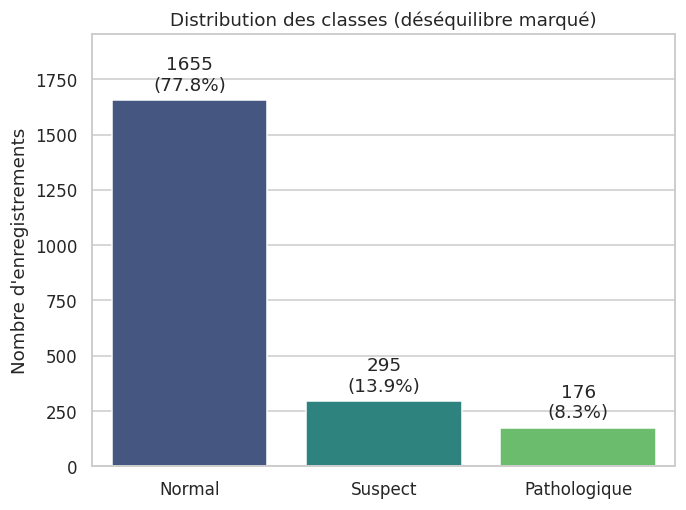

In [4]:
counts = df["fetal_health"].value_counts().sort_index()
ax = sns.barplot(x=[CLASS_NAMES[int(i)-1] for i in counts.index], y=counts.values,
                 hue=[CLASS_NAMES[int(i)-1] for i in counts.index],
                 palette="viridis", legend=False)
ax.set_ylim(0, counts.values.max() * 1.18)  # marge en haut pour les étiquettes
offset = counts.values.max() * 0.015
for i, v in enumerate(counts.values):
    ax.text(i, v + offset, f"{v}\n({v/len(df):.1%})", ha="center", va="bottom")
ax.set_ylabel("Nombre d'enregistrements"); ax.set_xlabel("")
ax.set_title("Distribution des classes (déséquilibre marqué)")
plt.tight_layout(); plt.show()

### 3.2 Corrélations entre variables

Plusieurs mesures dérivées de l'histogramme du rythme cardiaque sont fortement
corrélées entre elles.

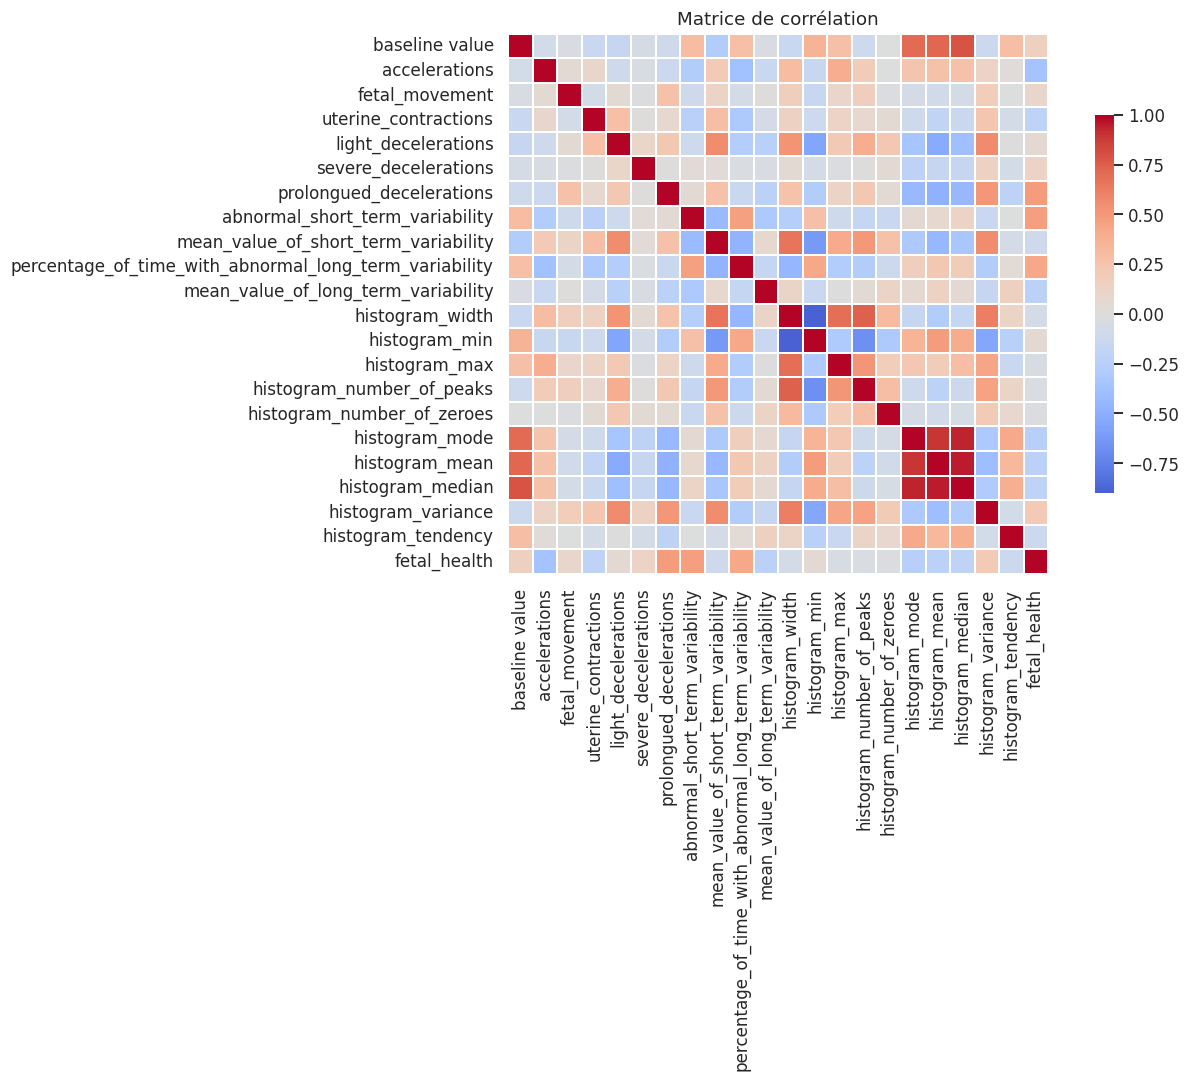

In [5]:
plt.figure(figsize=(13, 10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .7}, linewidths=.3)
plt.title("Matrice de corrélation")
plt.tight_layout(); plt.show()

In [6]:
target_corr = corr["fetal_health"].drop("fetal_health").sort_values(key=np.abs, ascending=False)
target_corr.to_frame("corrélation avec fetal_health")

,corrélation avec fetal_health
prolongued_decelerations,0.484859
abnormal_short_term_variability,0.471191
percentage_of_time_with_abnormal_long_term_variability,0.426146
accelerations,-0.364066
histogram_mode,-0.250412
histogram_mean,-0.226985
mean_value_of_long_term_variability,-0.226797
histogram_variance,0.206630
histogram_median,-0.205033
uterine_contractions,-0.204894


### 3.3 Variables discriminantes par classe

On visualise la distribution des variables les plus corrélées à la cible, classe
par classe. On retrouve déjà des tendances cohérentes avec la clinique : la
variabilité court terme anormale augmente avec la gravité, tandis que les
accélérations sont surtout présentes dans les cas normaux.

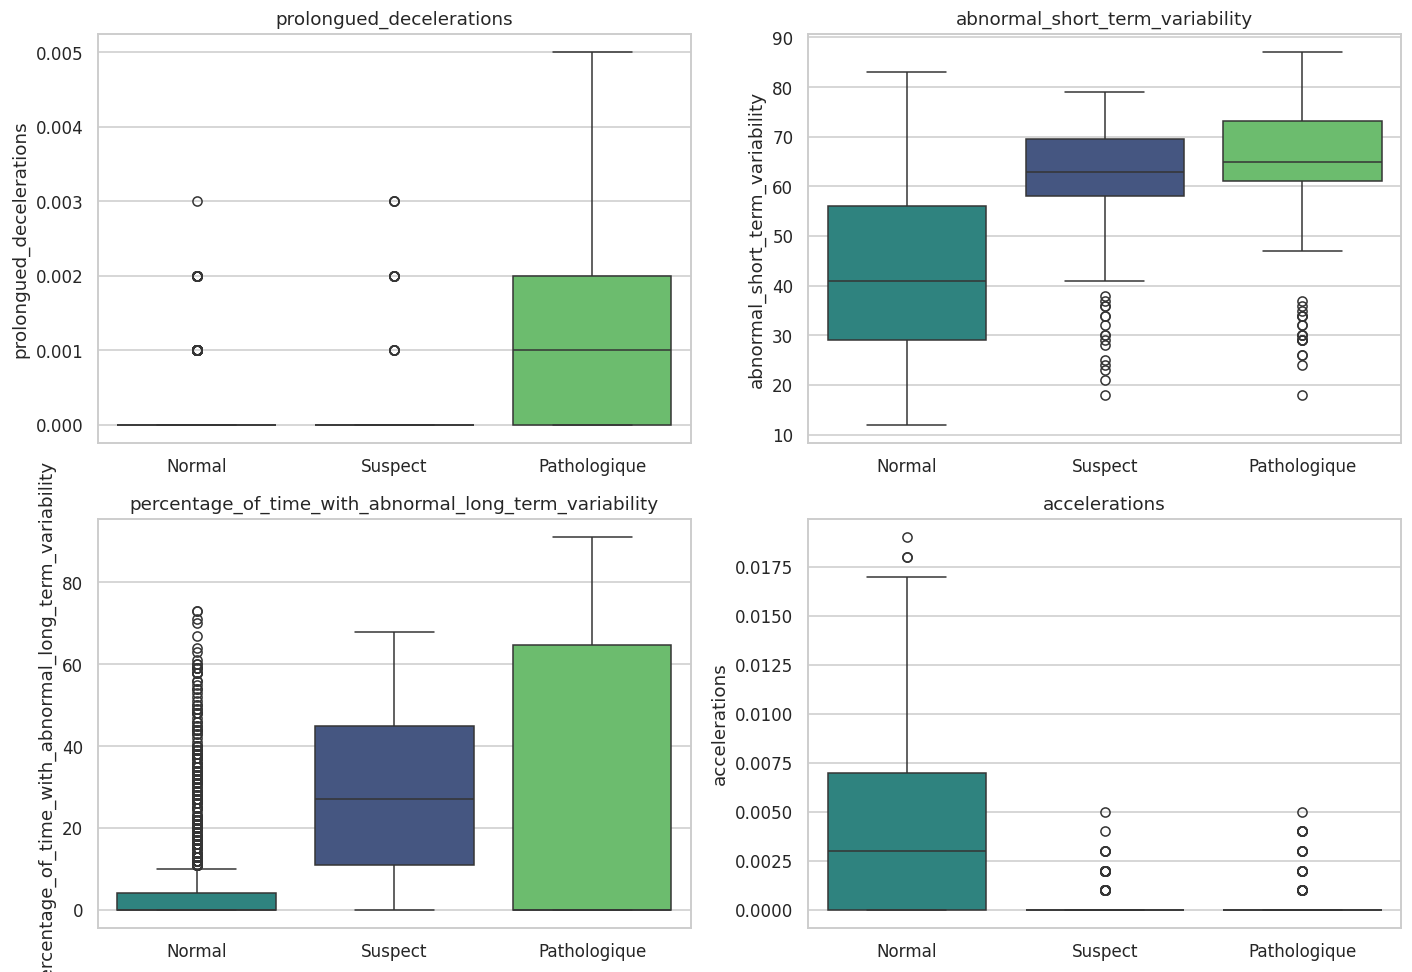

In [7]:
top_feats = target_corr.index[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
df_plot = df.copy()
df_plot["classe"] = df_plot["fetal_health"].map({1: "Normal", 2: "Suspect", 3: "Pathologique"})
order = ["Normal", "Suspect", "Pathologique"]
for ax, feat in zip(axes.ravel(), top_feats):
    sns.boxplot(data=df_plot, x="classe", y=feat, order=order,
                hue="classe", palette="viridis", legend=False, ax=ax)
    ax.set_title(feat); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Préparation des données

Trois opérations. On recode les classes de {1, 2, 3} vers {0, 1, 2}, car XGBoost
attend des étiquettes commençant à zéro. On sépare ensuite les données en 80 %
d'entraînement et 20 % de test, en stratifiant pour conserver la proportion des
classes rares. Enfin, on calcule des poids d'échantillons équilibrés pour
compenser le déséquilibre pendant l'entraînement.

In [8]:
X = df.drop(columns=["fetal_health"])
y = df["fetal_health"].astype(int) - 1   # {1,2,3} -> {0,1,2}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Poids d'échantillons équilibrés (réutilisés par tous les modèles)
sample_w = compute_sample_weight(class_weight="balanced", y=y_train)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("\nProportions par classe (train) :")
print((y_train.value_counts(normalize=True).sort_index()
       .rename(index=lambda i: CLASS_NAMES[i])).round(3))

Train : (1700, 21) | Test : (426, 21)

Proportions par classe (train) :
fetal_health
Normal          0.778
Suspect         0.139
Pathologique    0.083
Name: proportion, dtype: float64


## 5. Sélection de variables

Les 21 mesures ne sont pas toutes utiles et certaines font double emploi. En
réduire le nombre présente deux avantages : un modèle un peu plus robuste, et
surtout des explications nettement plus lisibles pour un expert. Dix variables
se commentent mieux que vingt et une.

Pour choisir, on entraîne un XGBoost de référence, on classe les variables par
importance (le gain qu'elles apportent aux arbres), puis on mesure la performance
d'un modèle restreint aux k variables les plus importantes. On retient le plus
petit k qui ne fait pas perdre de F1 macro.

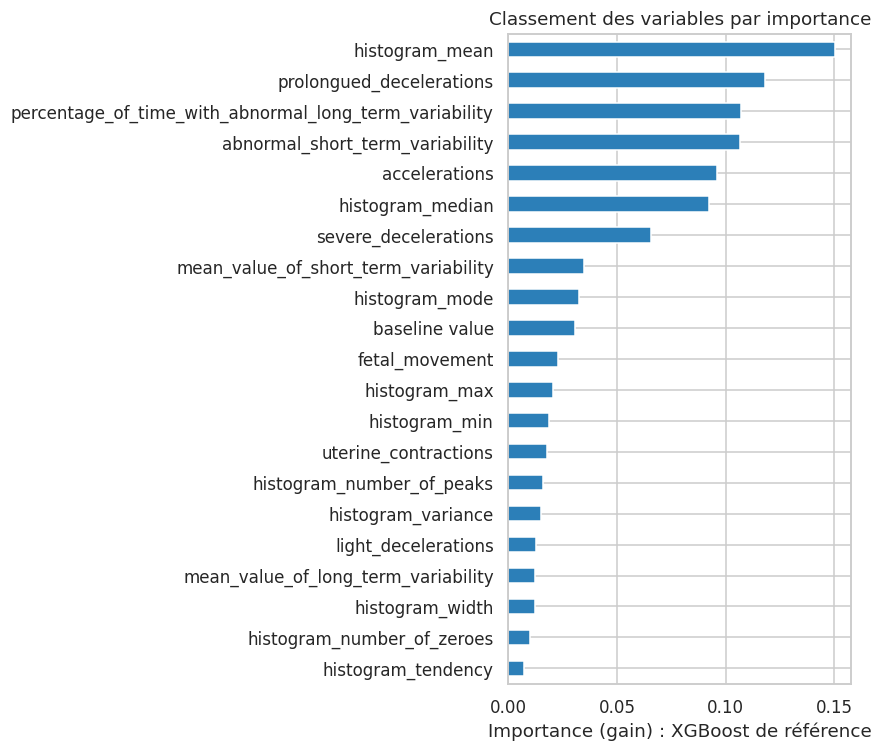

In [9]:
baseline = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.9,
    colsample_bytree=0.9, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
baseline.fit(X_train, y_train, sample_weight=sample_w)

imp = (pd.Series(baseline.feature_importances_, index=X_train.columns)
       .sort_values(ascending=False))

plt.figure(figsize=(8, 7))
imp.sort_values().tail(21).plot(kind="barh", color="#2c7fb8")
plt.xlabel("Importance (gain) : XGBoost de référence")
plt.title("Classement des variables par importance")
plt.tight_layout(); plt.show()

In [10]:
# Performance selon le nombre k de variables conservées
rows = []
for k in [6, 8, 10, 12, 21]:
    feats = imp.head(k).index.tolist()
    m = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                      subsample=0.9, colsample_bytree=0.9, eval_metric="mlogloss",
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    m.fit(X_train[feats], y_train, sample_weight=sample_w)
    p = m.predict(X_test[feats])
    rows.append({"k variables": k,
                 "F1 macro": f1_score(y_test, p, average="macro"),
                 "Accuracy": accuracy_score(y_test, p)})
sel_table = pd.DataFrame(rows).set_index("k variables")
sel_table.style.format("{:.3f}").background_gradient(cmap="Greens")

,F1 macro,Accuracy
k variables,,
6,0.873,0.925
8,0.880,0.930
10,0.904,0.946
12,0.892,0.941
21,0.885,0.937


On voit dans le tableau que se limiter aux 10 variables les plus importantes ne
coûte rien : sur notre découpage, la performance progresse même un peu (F1 macro
de 0.90 et accuracy de 0.95, contre 0.88 et 0.93 avec les 21 variables), le
retrait des mesures redondantes faisant plutôt du bien. Nous gardons donc ces 10
variables pour la suite. C'est un premier compromis favorable, puisqu'on gagne en
lisibilité sans rien perdre en performance.

In [11]:
SELECTED = imp.head(10).index.tolist()
X_train_sel = X_train[SELECTED]
X_test_sel = X_test[SELECTED]
print("Variables retenues :")
for i, f in enumerate(SELECTED, 1):
    print(f"  {i:>2}. {f}")

Variables retenues :
   1. histogram_mean
   2. prolongued_decelerations
   3. percentage_of_time_with_abnormal_long_term_variability
   4. abnormal_short_term_variability
   5. accelerations
   6. histogram_median
   7. severe_decelerations
   8. mean_value_of_short_term_variability
   9. histogram_mode
  10. baseline value


## 6. Comparaison de modèles

On compare quatre modèles qui couvrent tout l'éventail de l'interprétabilité, du
plus transparent au plus opaque : une régression logistique et un arbre de
décision, tous deux interprétables d'eux-mêmes (ante-hoc), puis une forêt
aléatoire et un XGBoost, nettement moins lisibles. Les quatre sont entraînés sur
les 10 variables retenues, avec pondération des classes. Le critère d'arbitrage
est le F1 macro.

In [12]:
models = {
    "Régression logistique": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                   random_state=RANDOM_STATE))]),
    "Arbre de décision": DecisionTreeClassifier(
        max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.9,
        colsample_bytree=0.9, eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

results = {}
for name, model in models.items():
    if name == "XGBoost":
        model.fit(X_train_sel, y_train, sample_weight=sample_w)
    else:
        model.fit(X_train_sel, y_train)
    pred = model.predict(X_test_sel)
    results[name] = {
        "model": model, "pred": pred,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "f1_path": f1_score(y_test, pred, average=None)[2],  # F1 classe Pathologique
    }
    print(f"{name:<25} acc={results[name]['accuracy']:.3f}  "
          f"f1_macro={results[name]['f1_macro']:.3f}  "
          f"f1_pathologique={results[name]['f1_path']:.3f}")

Régression logistique     acc=0.838  f1_macro=0.748  f1_pathologique=0.709
Arbre de décision         acc=0.756  f1_macro=0.723  f1_pathologique=0.821


Random Forest             acc=0.927  f1_macro=0.864  f1_pathologique=0.901


XGBoost                   acc=0.946  f1_macro=0.904  f1_pathologique=0.904


In [13]:
comparison = pd.DataFrame({
    n: {"Accuracy": r["accuracy"], "F1 macro": r["f1_macro"],
        "F1 (Pathologique)": r["f1_path"]}
    for n, r in results.items()}).T.sort_values("F1 macro", ascending=False)
comparison.style.format("{:.3f}").background_gradient(cmap="Greens")

,Accuracy,F1 macro,F1 (Pathologique)
XGBoost,0.946,0.904,0.904
Random Forest,0.927,0.864,0.901
Régression logistique,0.838,0.748,0.709
Arbre de décision,0.756,0.723,0.821


Les deux modèles d'ensemble dominent : XGBoost obtient le meilleur F1 macro
(0.90), devant la forêt aléatoire (0.86), alors que l'arbre (0.72) et la
régression logistique (0.75) restent loin derrière. L'écart vient surtout de la
classe Suspect, que les modèles transparents classent mal (F1 autour de 0.52 pour
l'arbre, 0.63 pour la régression). Nous reviendrons sur ce compromis à la section
11. Avant cela, profitons de ce que les modèles transparents savent le mieux
faire : se laisser lire.

## 7. Interprétation des modèles transparents

La consigne demande d'exploiter réellement l'interprétabilité native d'au moins un
modèle transparent, et pas seulement de l'afficher. C'est ce que nous faisons ici
avec l'arbre et la régression logistique.

### 7.1 Arbre de décision : extraction des règles

L'arbre encode des règles de décision lisibles directement. On le visualise, puis
on en extrait les règles sous forme textuelle.

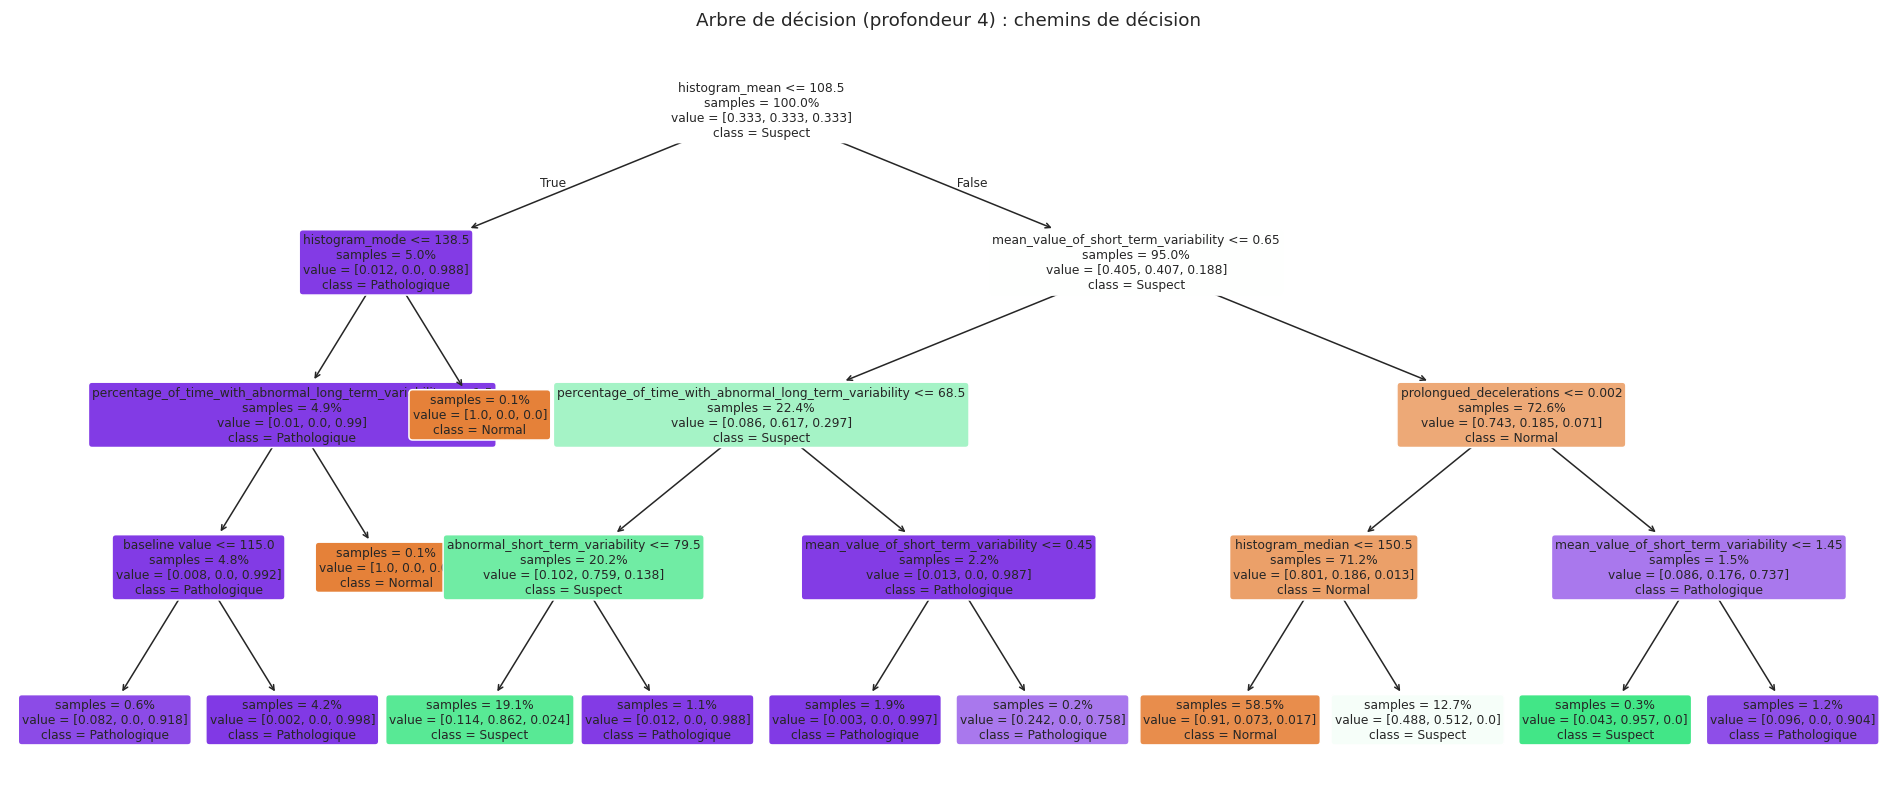

In [14]:
tree = results["Arbre de décision"]["model"]
plt.figure(figsize=(22, 9))
plot_tree(tree, feature_names=SELECTED, class_names=CLASS_NAMES,
          filled=True, rounded=True, fontsize=8, impurity=False, proportion=True)
plt.title("Arbre de décision (profondeur 4) : chemins de décision")
plt.show()

In [15]:
print(export_text(tree, feature_names=list(SELECTED), max_depth=3))

|--- histogram_mean <= 108.50
|   |--- histogram_mode <= 138.50
|   |   |--- percentage_of_time_with_abnormal_long_term_variability <= 1.50
|   |   |   |--- baseline value <= 115.00
|   |   |   |   |--- class: 2
|   |   |   |--- baseline value >  115.00
|   |   |   |   |--- class: 2
|   |   |--- percentage_of_time_with_abnormal_long_term_variability >  1.50
|   |   |   |--- class: 0
|   |--- histogram_mode >  138.50
|   |   |--- class: 0
|--- histogram_mean >  108.50
|   |--- mean_value_of_short_term_variability <= 0.65
|   |   |--- percentage_of_time_with_abnormal_long_term_variability <= 68.50
|   |   |   |--- abnormal_short_term_variability <= 79.50
|   |   |   |   |--- class: 1
|   |   |   |--- abnormal_short_term_variability >  79.50
|   |   |   |   |--- class: 2
|   |   |--- percentage_of_time_with_abnormal_long_term_variability >  68.50
|   |   |   |--- mean_value_of_short_term_variability <= 0.45
|   |   |   |   |--- class: 2
|   |   |   |--- mean_value_of_short_term_variabilit

L'arbre se lit comme une suite de règles. Sa première coupure porte sur
`histogram_mean`, la moyenne du rythme cardiaque sur l'histogramme, au seuil de
108,5, ce qui sépare déjà bien les tracés. En descendant jusqu'à une feuille, on
obtient des règles compréhensibles. Par exemple, l'une des branches menant à la
classe Pathologique se lit ainsi : si la variabilité court terme moyenne est très
faible (`mean_value_of_short_term_variability` au plus 0,65) et que le fœtus passe
une grande partie du temps avec une variabilité long terme anormale (plus de
68,5 %), l'arbre prédit Pathologique, ce qui concerne 33 cas. Une faible
variabilité associée à une variabilité long terme durablement anormale est un
signe de souffrance reconnu, ce qui rend la règle crédible. Tout l'intérêt d'un
modèle transparent est là : son explication est le modèle lui-même. Le revers est
une performance plus faible, car il simplifie une réalité non linéaire.

### 7.2 Régression logistique : lecture des coefficients

La régression logistique multinomiale apprend, pour chaque classe, un coefficient
par variable. Comme les données sont standardisées, ces coefficients sont
comparables entre eux : un coefficient positif pousse vers la classe, un
coefficient négatif l'en éloigne.

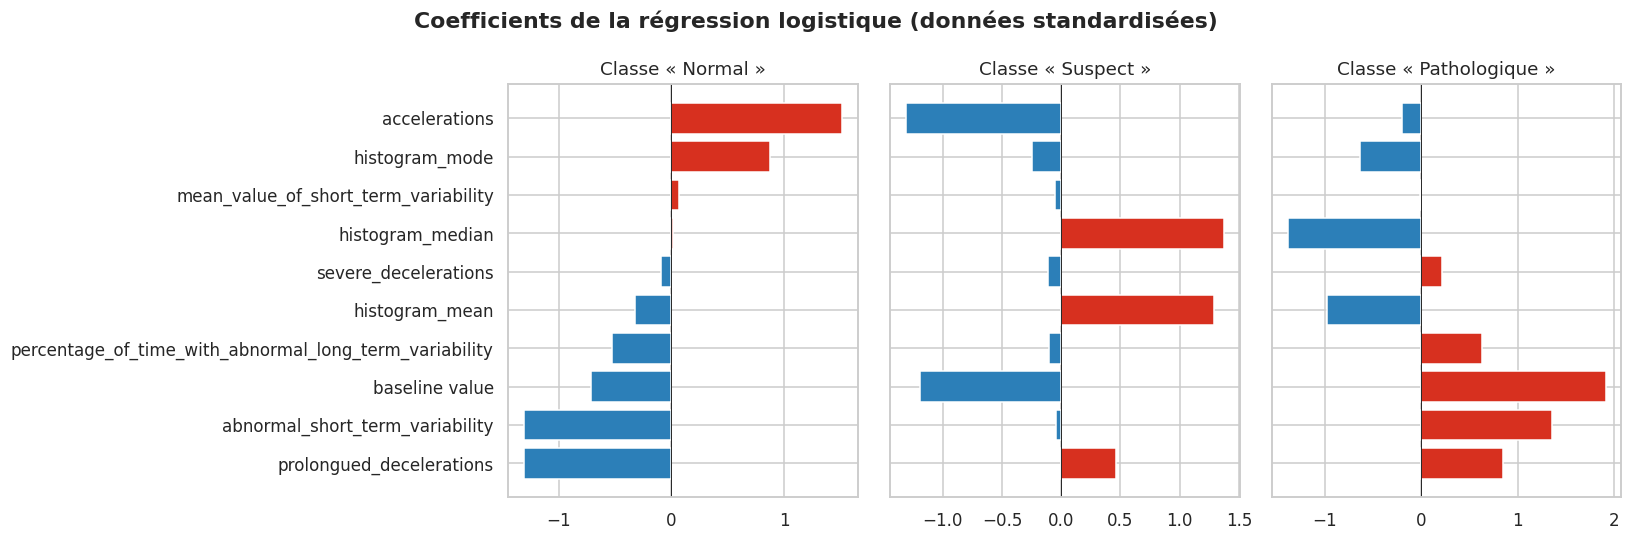

,Normal,Suspect,Pathologique
histogram_mean,-0.32,1.29,-0.97
prolongued_decelerations,-1.31,0.46,0.85
percentage_of_time_with_abnormal_long_term_variability,-0.53,-0.10,0.63
abnormal_short_term_variability,-1.31,-0.04,1.35
accelerations,1.51,-1.31,-0.20
histogram_median,0.01,1.37,-1.38
severe_decelerations,-0.10,-0.11,0.21
mean_value_of_short_term_variability,0.06,-0.05,-0.01
histogram_mode,0.87,-0.24,-0.63
baseline value,-0.72,-1.19,1.91


In [16]:
logreg = results["Régression logistique"]["model"].named_steps["clf"]
coef = pd.DataFrame(logreg.coef_, columns=SELECTED, index=CLASS_NAMES).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, cls in zip(axes, CLASS_NAMES):
    s = coef[cls].sort_values()
    ax.barh(s.index, s.values, color=np.where(s.values > 0, "#d7301f", "#2c7fb8"))
    ax.axvline(0, color="k", lw=.6)
    ax.set_title(f"Classe « {cls} »")
plt.suptitle("Coefficients de la régression logistique (données standardisées)",
             fontweight="bold")
plt.tight_layout(); plt.show()
coef.round(2)

Pour la classe Pathologique, les coefficients positifs les plus marqués sont ceux
de `baseline value`, de `abnormal_short_term_variability` et des
`prolongued_decelerations` : quand ces mesures augmentent, la prédiction se
déplace vers le risque. À l'inverse, `histogram_median`, `histogram_mean` et les
`accelerations` ont des coefficients négatifs, donc des accélérations présentes et
un rythme de base dans la norme éloignent du diagnostic pathologique. La plupart
de ces tendances correspondent à ce qu'on attend cliniquement. Le poids élevé de
`baseline value` est toutefois à nuancer : la régression étant linéaire et
plusieurs variables étant corrélées, ce coefficient capte probablement en partie
l'effet d'autres mesures.

## 8. Modèle retenu : XGBoost

XGBoost obtient le meilleur F1 macro et le meilleur score sur la classe
Pathologique. Comme l'objectif du projet est l'explication, c'est aussi le cas le
plus intéressant : il s'agit d'une boîte noire, faite de centaines d'arbres, qu'on
ne peut pas lire directement. On l'expliquera donc après coup avec SHAP et LIME.
On le réentraîne ici proprement sur les 10 variables sélectionnées.

In [17]:
final_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.9,
    colsample_bytree=0.9, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
final_model.fit(X_train_sel, y_train, sample_weight=sample_w)

final_pred = final_model.predict(X_test_sel)
print("Modèle final : XGBoost (10 variables)")
print(f"Accuracy test : {accuracy_score(y_test, final_pred):.3f}")
print(f"F1 macro test : {f1_score(y_test, final_pred, average='macro'):.3f}")

Modèle final : XGBoost (10 variables)
Accuracy test : 0.946
F1 macro test : 0.904


### 8.1 Évaluation détaillée

Le rapport par classe et les matrices de confusion montrent où sont les erreurs.
L'erreur la plus grave sur le plan clinique est le faux négatif pathologique,
c'est-à-dire un fœtus en souffrance classé Normal.

In [18]:
print(classification_report(y_test, final_pred, target_names=CLASS_NAMES, digits=3))

              precision    recall  f1-score   support

      Normal      0.973     0.967     0.970       332
     Suspect      0.845     0.831     0.838        59
Pathologique      0.868     0.943     0.904        35

    accuracy                          0.946       426
   macro avg      0.895     0.913     0.904       426
weighted avg      0.946     0.946     0.946       426



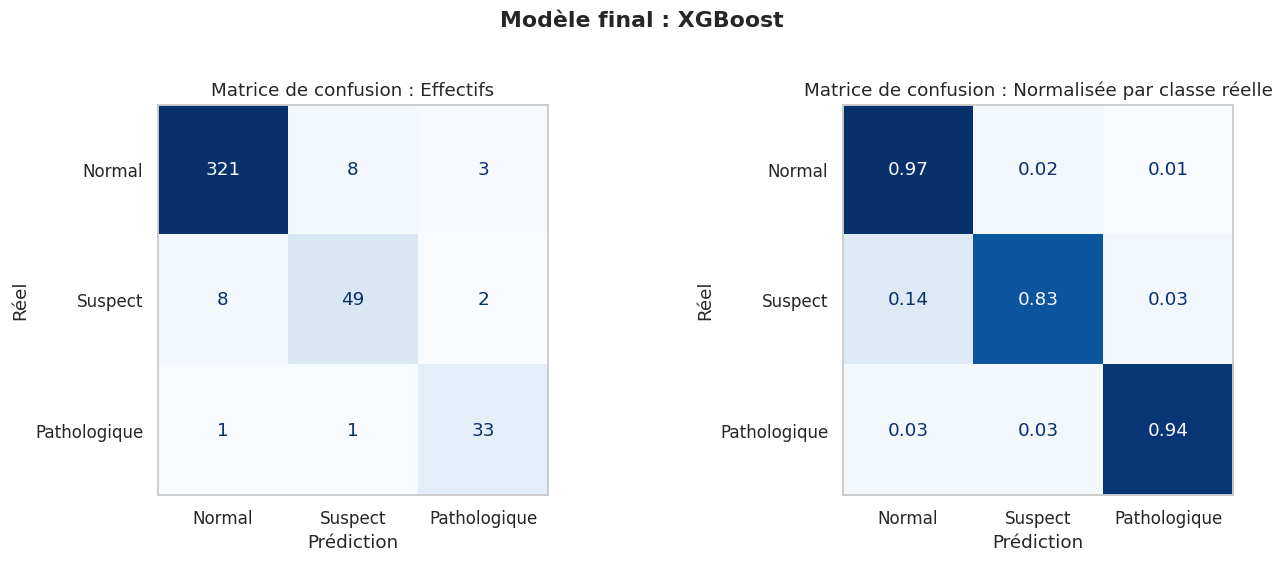

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, normalize, title in zip(axes, [None, "true"],
                                ["Effectifs", "Normalisée par classe réelle"]):
    cm = confusion_matrix(y_test, final_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False,
              values_format=".2f" if normalize else "d")
    ax.set_title(f"Matrice de confusion : {title}")
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Réel"); ax.grid(False)
plt.suptitle("Modèle final : XGBoost", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()

Le modèle est très fiable sur les cas normaux (321 sur 332)
et il isole bien les cas pathologiques (33 sur 35). La
classe la plus difficile est en réalité Suspect, et elle se confond surtout avec
Normal : sur les 59 cas suspects, 8 sont vus comme normaux et 2 seulement comme
pathologiques. Symétriquement, 8 cas normaux sont jugés suspects. La frontière la
plus floue est donc Normal contre Suspect, et non Suspect contre Pathologique. Un
seul cas pathologique a été classé Normal : c'est le faux négatif que nous
analyserons en détail.

## 9. Explicabilité post-hoc avec SHAP

SHAP (SHapley Additive exPlanations) attribue à chaque variable une part de
l'écart entre la prédiction d'un cas et la prédiction moyenne, en s'appuyant sur
les valeurs de Shapley issues de la théorie des jeux. La méthode est additive et
cohérente, et elle passe naturellement du local (un patient) au global (par
agrégation). Comme XGBoost est un modèle d'arbres, `TreeExplainer` calcule ces
valeurs de manière exacte et rapide. En multiclasse, SHAP produit un jeu de
valeurs par classe.

In [20]:
explainer = shap.TreeExplainer(final_model)
shap_exp = explainer(X_test_sel)   # Explanation : (n_échantillons, n_variables, n_classes)
print("Forme des valeurs SHAP :", shap_exp.values.shape)

Forme des valeurs SHAP : (426, 10, 3)


### 9.1 Interprétation globale

Pour savoir quelles variables comptent le plus dans l'ensemble, on moyenne
l'amplitude des valeurs SHAP sur tout le jeu de test.

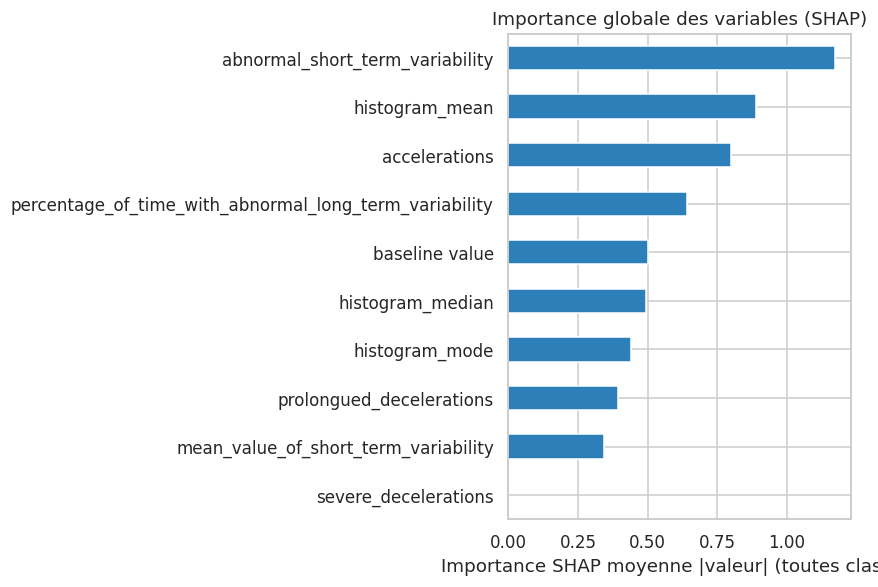

In [21]:
mean_abs = np.abs(shap_exp.values).mean(axis=(0, 2))
glob = pd.Series(mean_abs, index=SELECTED).sort_values()
plt.figure(figsize=(8, 5.5))
glob.plot(kind="barh", color="#2c7fb8")
plt.xlabel("Importance SHAP moyenne |valeur| (toutes classes)")
plt.title("Importance globale des variables (SHAP)")
plt.tight_layout(); plt.show()

Beeswarm : contributions vers la classe « Pathologique »


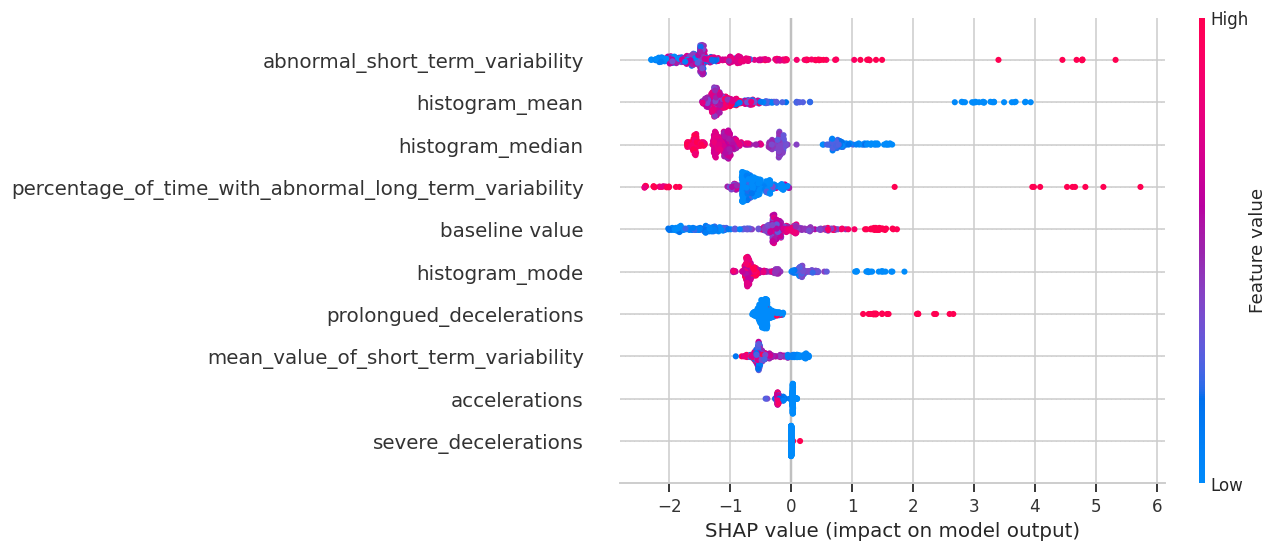

In [22]:
PATHO = 2  # classe Pathologique
print(f"Beeswarm : contributions vers la classe « {CLASS_NAMES[PATHO]} »")
shap.plots.beeswarm(shap_exp[:, :, PATHO], max_display=10, show=True)

Sur le bar plot, les variables qui pèsent le plus globalement sont la variabilité
court terme anormale (`abnormal_short_term_variability`), la moyenne de
l'histogramme (`histogram_mean`), les accélérations et le pourcentage de temps à
variabilité long terme anormale. À l'inverse, les décélérations sévères
n'interviennent presque jamais dans ce modèle.

Le beeswarm se lit ainsi : chaque point est un patient, sa position horizontale
donne sa valeur SHAP (vers la droite, la variable pousse vers Pathologique) et sa
couleur indique la valeur de la mesure (rouge pour élevée, bleu pour faible). Pour
`abnormal_short_term_variability`, on retrouve la tendance déjà vue sur les
boxplots : des valeurs élevées tirent plutôt vers le diagnostic pathologique.

### 9.2 Effet d'une variable (dependence plot)

Le dependence plot montre comment la valeur SHAP d'une variable évolue avec sa
valeur réelle.

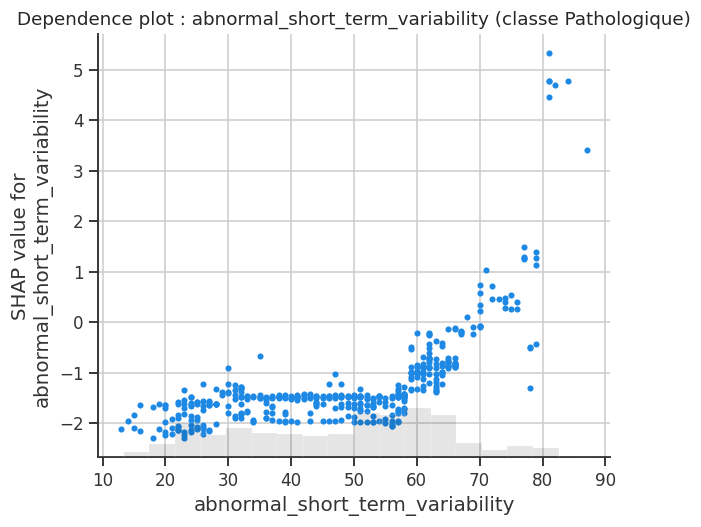

In [23]:
top_feat = glob.index[-1]
shap.plots.scatter(shap_exp[:, top_feat, PATHO], show=False)
plt.title(f"Dependence plot : {top_feat} (classe {CLASS_NAMES[PATHO]})")
plt.show()

### 9.3 Explications locales et choix des cas

On examine trois cas, chacun choisi pour une raison précise. Le premier est un cas
pathologique correctement classé, pour voir à quoi ressemble une vraie alerte du
point de vue du modèle. Le deuxième est un cas normal correctement classé, pour
voir ce qui le rassure. Le troisième est le faux négatif pathologique, un tracé
réellement pathologique que le modèle a classé Normal. C'est le cas le plus
instructif, car comprendre pourquoi le modèle s'est trompé est indispensable pour
juger jusqu'où lui faire confiance.

In [24]:
# (A) et (B) : cas bien classés
examples = {}
for c in [PATHO, 0]:
    mask = (y_test.values == c) & (final_pred == c)
    examples[c] = int(np.where(mask)[0][0])

# (C) : faux négatif pathologique (patho réel prédit comme non-patho)
err_mask = (y_test.values == PATHO) & (final_pred != PATHO)
fn_pos = int(np.where(err_mask)[0][0]) if err_mask.any() else None

print("Cas (A) Pathologique bien classé  -> position test", examples[PATHO])
print("Cas (B) Normal bien classé        -> position test", examples[0])
if fn_pos is not None:
    print(f"Cas (C) Faux négatif pathologique -> position test {fn_pos} "
          f"(réel=Pathologique, prédit={CLASS_NAMES[final_pred[fn_pos]]})")

Cas (A) Pathologique bien classé  -> position test 34
Cas (B) Normal bien classé        -> position test 0
Cas (C) Faux négatif pathologique -> position test 117 (réel=Pathologique, prédit=Normal)


(A) Cas Pathologique bien classé : pourquoi le modèle alerte (test #34)


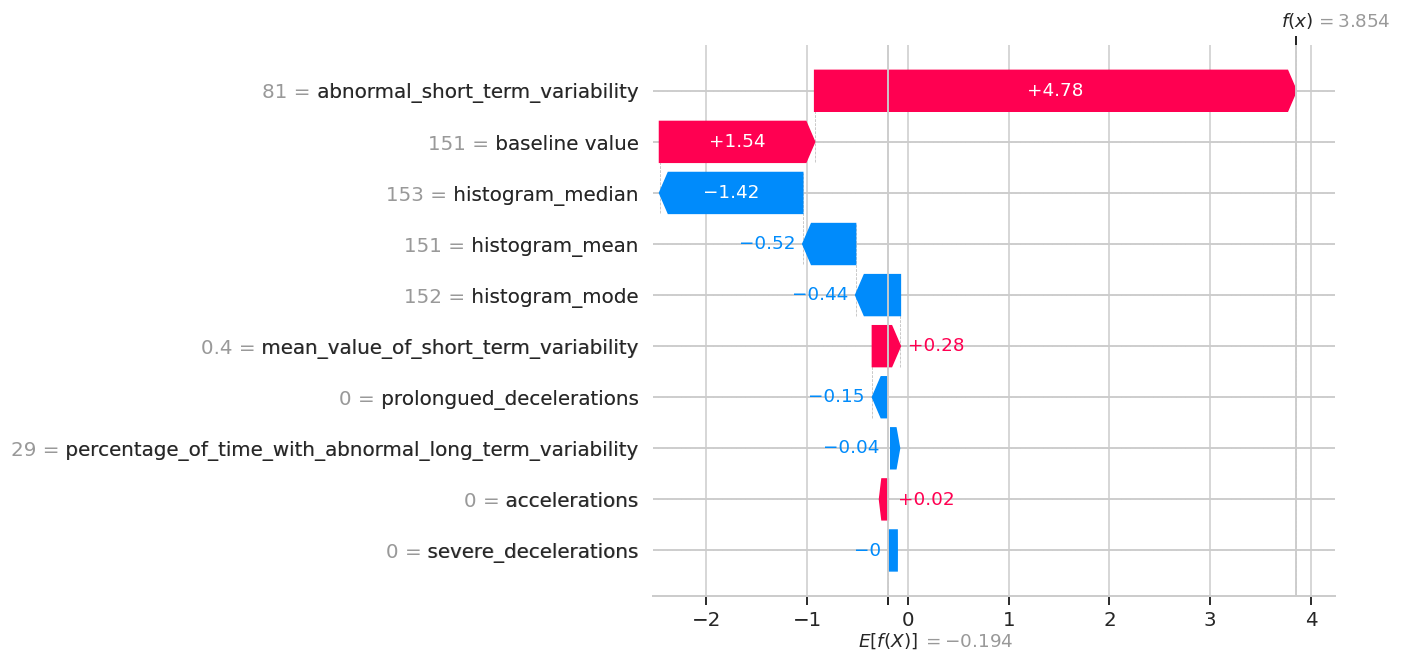

In [25]:
# (A) Cas pathologique typique, bien classé : waterfall pour la classe Pathologique
pos = examples[PATHO]
print(f"(A) Cas Pathologique bien classé : pourquoi le modèle alerte (test #{pos})")
shap.plots.waterfall(shap_exp[pos, :, PATHO], max_display=10, show=True)

(B) Cas Normal bien classé : ce qui rassure le modèle (test #0)


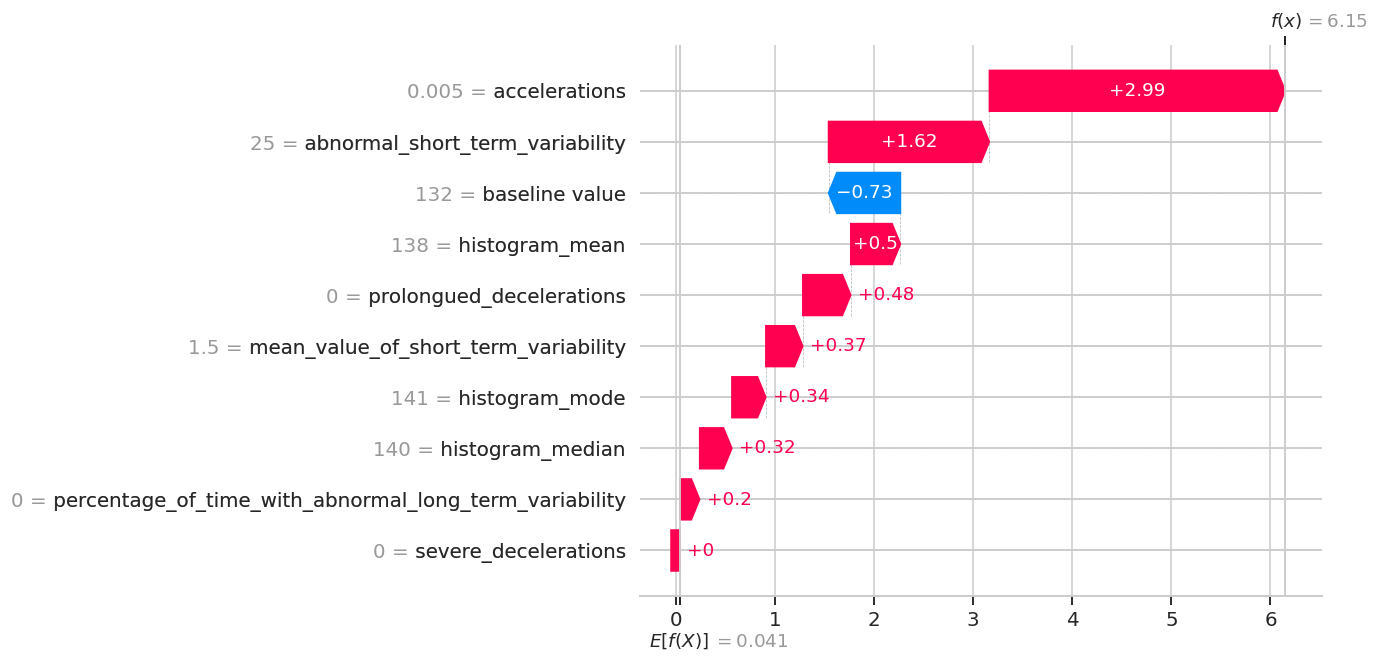

In [26]:
# (B) Cas normal typique, bien classé : waterfall pour la classe Normal
pos = examples[0]
print(f"(B) Cas Normal bien classé : ce qui rassure le modèle (test #{pos})")
shap.plots.waterfall(shap_exp[pos, :, 0], max_display=10, show=True)

(C) Faux négatif : réel=Pathologique, prédit=Normal (test #117)

>> Pourquoi le modèle a choisi « Normal » :


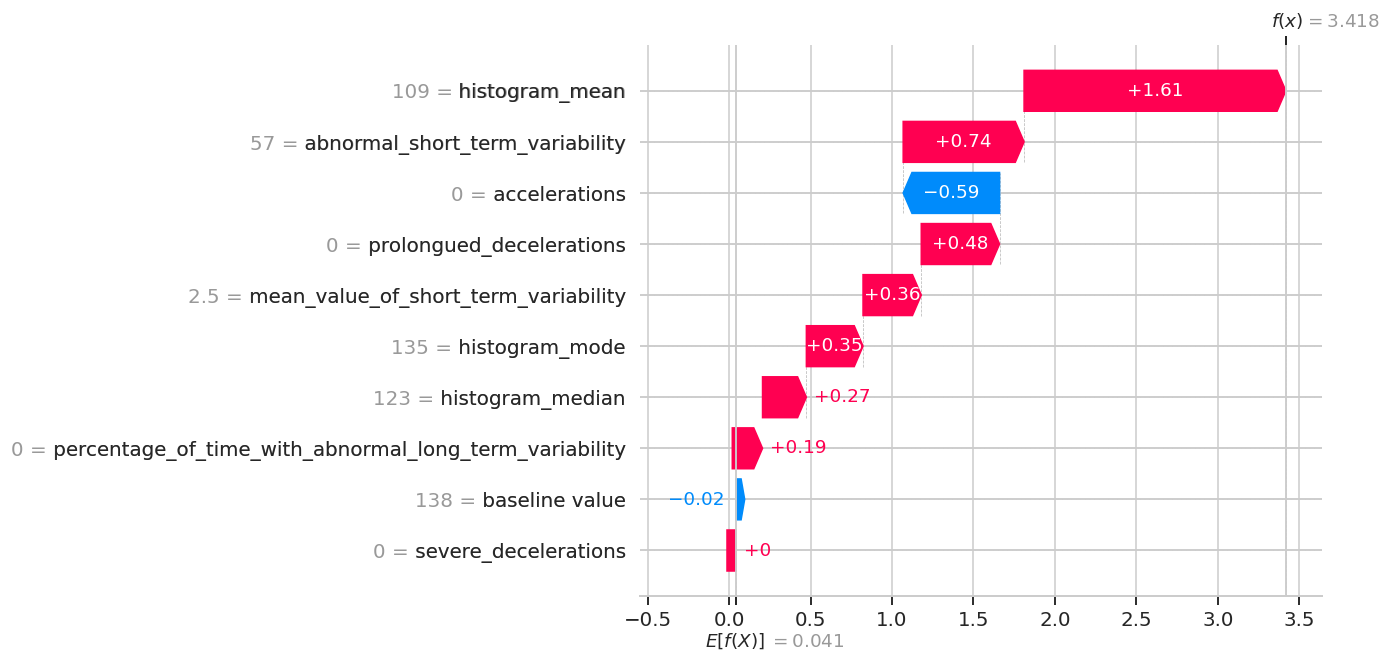


>> Ce qui manquait pour déclencher l'alerte « Pathologique » :


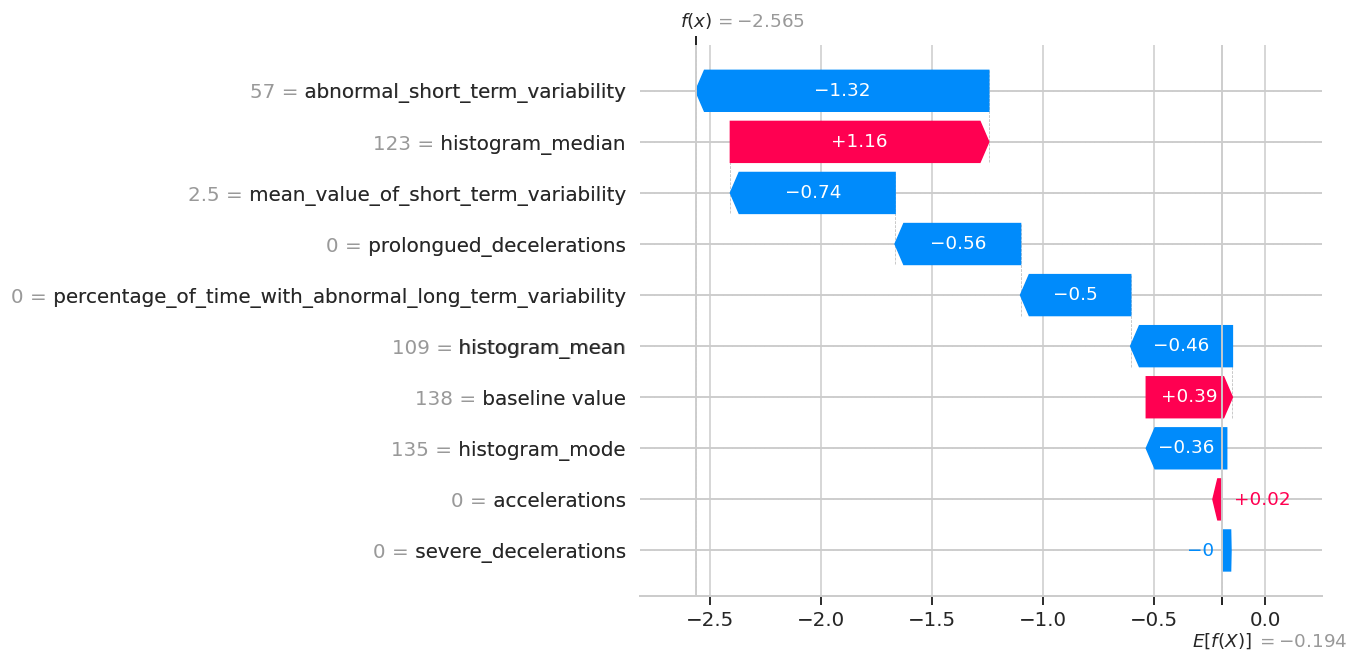

In [27]:
# (C) Faux négatif pathologique : on examine la classe prédite ET la classe réelle
if fn_pos is not None:
    pred_c = int(final_pred[fn_pos])
    print(f"(C) Faux négatif : réel=Pathologique, prédit={CLASS_NAMES[pred_c]} (test #{fn_pos})")
    print(f"\n>> Pourquoi le modèle a choisi « {CLASS_NAMES[pred_c]} » :")
    shap.plots.waterfall(shap_exp[fn_pos, :, pred_c], max_display=10, show=True)
    print(f"\n>> Ce qui manquait pour déclencher l'alerte « Pathologique » :")
    shap.plots.waterfall(shap_exp[fn_pos, :, PATHO], max_display=10, show=True)

Le waterfall part du score moyen de la classe (noté E[f(x)], en log-odds) et
empile les contributions de chaque variable, en rouge quand elles font monter le
score et en bleu quand elles le font baisser, jusqu'au score final f(x).

Le faux négatif est éclairant. Ce tracé était bien pathologique, mais il ne
présentait aucun des signaux d'alarme habituels : pas de décélération prolongée ni
sévère, et un pourcentage de temps à variabilité long terme anormale nul. Sa
moyenne d'histogramme (109) se situait juste au-dessus du seuil que l'arbre
associe aux cas graves, et l'absence de tout marqueur classique a tiré la décision
vers Normal. Le seul indice de risque, une variabilité court terme anormale autour
de 57 % et l'absence d'accélérations, n'a pas suffi. C'est exactement le genre
d'erreur qu'un clinicien doit garder à l'esprit plutôt que de faire une confiance
aveugle au modèle.

## 10. Explicabilité post-hoc avec LIME

LIME explique une prédiction en ajustant un petit modèle linéaire autour du cas
étudié, à partir de variantes légèrement perturbées de ce cas. Contrairement à
SHAP, il ne suppose rien sur le modèle expliqué et reste purement local, mais son
explication peut changer d'une exécution à l'autre selon le tirage aléatoire. On
l'applique aux mêmes cas que SHAP pour confronter les deux méthodes.

In [28]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_sel.values,
    feature_names=list(SELECTED),
    class_names=CLASS_NAMES,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE)

def predict_proba_fn(data):
    return final_model.predict_proba(pd.DataFrame(data, columns=SELECTED))

--- LIME : (A) Pathologique bien classé : explication pour « Pathologique » (test #34) ---


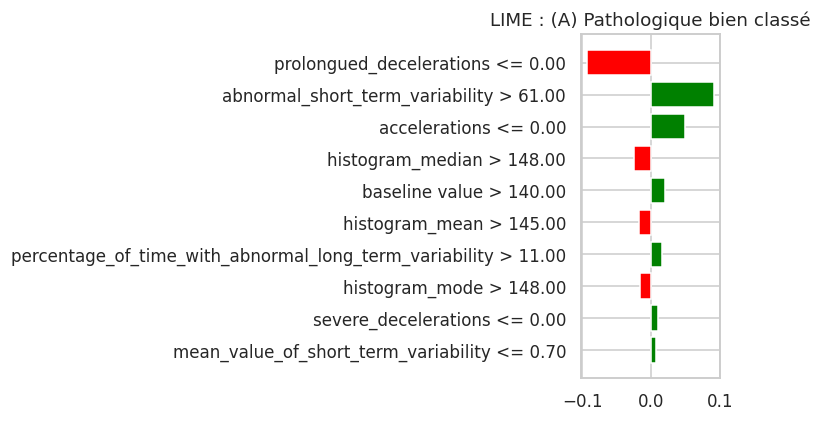

--- LIME : (C) Faux négatif pathologique : explication pour « Normal » (test #117) ---


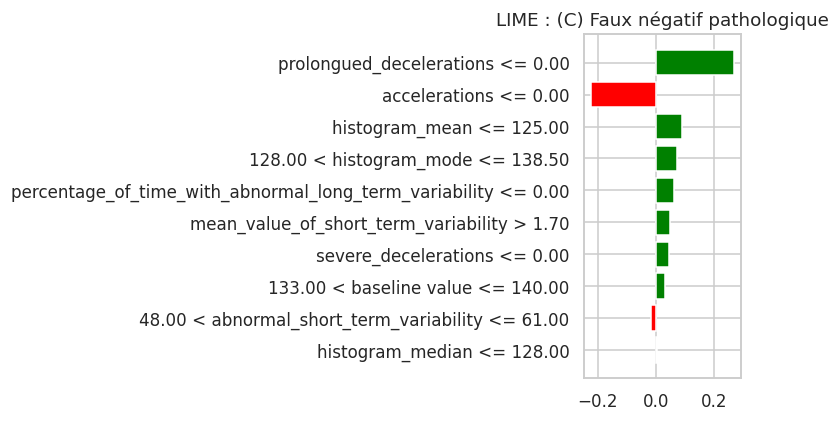

In [29]:
# Cas (A) pathologique bien classé et (C) faux négatif
to_explain = {"(A) Pathologique bien classé": (examples[PATHO], PATHO)}
if fn_pos is not None:
    to_explain["(C) Faux négatif pathologique"] = (fn_pos, int(final_pred[fn_pos]))

for label, (pos, cls) in to_explain.items():
    exp = lime_explainer.explain_instance(
        X_test_sel.iloc[pos].values, predict_proba_fn, num_features=10, labels=(cls,))
    print(f"--- LIME : {label} : explication pour « {CLASS_NAMES[cls]} » (test #{pos}) ---")
    fig = exp.as_pyplot_figure(label=cls); fig.set_size_inches(7, 4)
    plt.title(f"LIME : {label}"); plt.tight_layout(); plt.show()

### 10.1 SHAP face à LIME sur le cas pathologique

On compare directement les contributions données par les deux méthodes sur le même
cas. Quand elles désignent les mêmes variables, la confiance s'en trouve
renforcée ; quand elles divergent, c'est un signal de prudence.

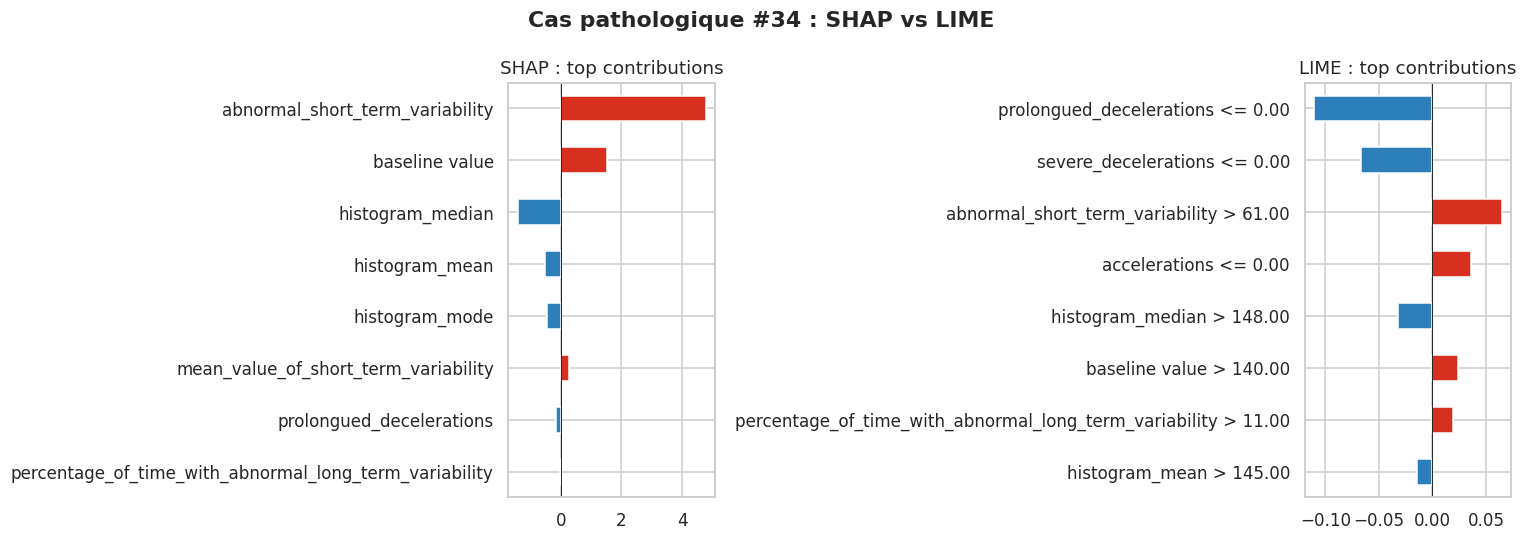

In [30]:
pos = examples[PATHO]
exp = lime_explainer.explain_instance(
    X_test_sel.iloc[pos].values, predict_proba_fn, num_features=10, labels=(PATHO,))
lime_imp = pd.Series(dict(exp.as_list(label=PATHO)))
lime_top = lime_imp.reindex(lime_imp.abs().sort_values(ascending=False).index).head(8)

shap_vals_case = pd.Series(shap_exp.values[pos, :, PATHO], index=SELECTED)
shap_top = shap_vals_case.reindex(shap_vals_case.abs().sort_values(ascending=False).index).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap_top[::-1].plot(kind="barh", ax=axes[0],
                    color=np.where(shap_top[::-1] > 0, "#d7301f", "#2c7fb8"))
axes[0].set_title("SHAP : top contributions"); axes[0].axvline(0, color="k", lw=.6)
lime_top[::-1].plot(kind="barh", ax=axes[1],
                    color=np.where(lime_top[::-1] > 0, "#d7301f", "#2c7fb8"))
axes[1].set_title("LIME : top contributions"); axes[1].axvline(0, color="k", lw=.6)
plt.suptitle(f"Cas pathologique #{pos} : SHAP vs LIME", fontweight="bold")
plt.tight_layout(); plt.show()

## 11. Compromis entre performance et interprétabilité

C'est le cœur de l'analyse. Deux familles d'approches s'opposent.

Avec les modèles transparents (l'arbre, la régression logistique), l'explication
est gratuite et totale : les règles et les coefficients se lisent directement, se
vérifient et se communiquent à un médecin sans outil supplémentaire, et il n'y a
aucun risque qu'une méthode tierce trahisse le modèle, puisque le modèle est sa
propre explication. En contrepartie, ils sont moins performants, en particulier
sur la classe Suspect, où leur F1 tombe autour de 0.52 pour l'arbre alors que
XGBoost atteint 0.84. L'arbre simplifie, et la régression suppose des effets
linéaires et additifs qui ne décrivent pas bien le problème.

Avec une boîte noire comme XGBoost expliquée a posteriori, on obtient la meilleure
performance, notamment sur les cas pathologiques. Le prix à payer est que
l'explication devient indirecte et approchée : SHAP et LIME sont eux-mêmes des
modèles d'explication, ils peuvent diverger (section 10.1), LIME est instable, et
la lecture est compliquée par les variables corrélées. Il faut un peu d'outillage
et d'habitude pour les interpréter correctement.

In [31]:
# Quantification du compromis
tradeoff = comparison.copy()
tradeoff["Type"] = ["post-hoc (boîte noire)" if n in ("XGBoost", "Random Forest")
                    else "ante-hoc (transparent)" for n in tradeoff.index]
tradeoff["Explication"] = ["SHAP / LIME (indirecte)" if n in ("XGBoost", "Random Forest")
                           else ("Règles" if n == "Arbre de décision" else "Coefficients")
                           for n in tradeoff.index]
print("Écart de performance ante-hoc vs post-hoc :")
gap = comparison.loc["XGBoost", "F1 (Pathologique)"] - comparison.loc["Arbre de décision", "F1 (Pathologique)"]
print(f"  F1 (Pathologique) : XGBoost surpasse l'arbre de +{gap:.3f}")
tradeoff[["Type", "Explication", "F1 macro", "F1 (Pathologique)"]]

Écart de performance ante-hoc vs post-hoc :
  F1 (Pathologique) : XGBoost surpasse l'arbre de +0.084


,Type,Explication,F1 macro,F1 (Pathologique)
XGBoost,post-hoc (boîte noire),SHAP / LIME (indirecte),0.903835,0.904110
Random Forest,post-hoc (boîte noire),SHAP / LIME (indirecte),0.864302,0.901408
Régression logistique,ante-hoc (transparent),Coefficients,0.748046,0.708861
Arbre de décision,ante-hoc (transparent),Règles,0.723260,0.820513


Dans ce contexte clinique, l'enjeu d'un faux négatif pathologique penche en faveur
de XGBoost, dont l'avantage sur les classes rares est significatif. La perte
d'interprétabilité native est en grande partie compensée par SHAP et LIME, qui
rendent chaque alerte auditable. Pour autant, l'arbre garde son utilité : ses
règles simples sont un bon support de communication, et quand SHAP et l'arbre
pointent les mêmes variables, on peut accorder davantage de confiance à
l'explication.

## 12. Robustesse, limites et questions cliniques

### 12.1 Réponses aux questions posées

Quelles anomalies poussent vers un diagnostic de risque, et lesquelles peuvent
tromper le modèle ? SHAP au niveau global et l'arbre désignent les mêmes mesures
principales : la variabilité court terme anormale, la moyenne de l'histogramme du
rythme, le pourcentage de temps à variabilité long terme anormale et l'absence
d'accélérations. Les variables d'histogramme, très corrélées entre elles, sont
aussi les plus susceptibles d'induire le modèle en erreur, car un rythme de base
d'apparence normale peut masquer une souffrance : c'est précisément ce qui s'est
produit sur le faux négatif de la section 9.3. On notera que les décélérations
sévères, contrairement à l'intuition, ne pèsent presque pas dans ce modèle, sans
doute parce qu'elles sont très rares dans les données.

Le modèle distingue-t-il bien les cas suspects des cas pathologiques ? Plutôt bien :
seuls 2 cas suspects sur 59 sont confondus avec un cas pathologique. La vraie
difficulté est ailleurs, entre Normal et Suspect, deux classes que le modèle
mélange dans les deux sens (8 cas dans chaque sens). La classe Pathologique, elle,
est bien isolée.

Peut-on se fier à la prédiction pour déclencher un suivi intensif ? Comme aide à la
décision, oui : le modèle s'appuie sur des signaux cliniquement valides et
explicables, et se trompe peu quand il alerte. En pleine autonomie, non : il a
laissé passer un cas pathologique en le classant Normal, ce qui est l'erreur la
plus dangereuse. Une prédiction Normal sur un tracé qui inquiète le clinicien doit
rester soumise à son jugement.

### 12.2 Limites et robustesse

Le déséquilibre des classes demeure, et malgré la pondération la classe Suspect
reste la plus difficile. Les variables d'histogramme corrélées rendent les
attributions SHAP délicates à interpréter. LIME dépend de son tirage aléatoire, ce
qui le rend moins fiable que SHAP pour appuyer une décision. La validation repose
sur un seul découpage : une validation croisée stratifiée donnerait une estimation
plus solide. Enfin, le modèle a été entraîné sur une seule source de données, et
sa fiabilité sur d'autres appareils ou populations resterait à vérifier.

### 12.3 Pistes d'amélioration

Une validation croisée avec recherche d'hyperparamètres, un rééchantillonnage des
classes rares, une calibration des probabilités et une analyse systématique des
faux négatifs pathologiques guidée par SHAP seraient les prolongements naturels de
ce travail.

## 13. Conclusion

Nous avons construit une chaîne complète et explicable pour classer la santé
fœtale. La sélection de variables a ramené le problème à 10 mesures tout en
améliorant légèrement la performance. La comparaison de modèles a couvert
l'éventail du transparent à la boîte noire, et nous avons réellement lu les
modèles transparents, à travers les règles de l'arbre et les coefficients de la
régression. Le meilleur modèle, XGBoost, a ensuite été expliqué avec SHAP et LIME,
globalement et sur des cas choisis, dont un faux négatif pathologique. Une section
a pesé le compromis entre performance et interprétabilité, et une autre a discuté
les limites.

L'idée à retenir est qu'un modèle à la fois performant et explicable n'a de
valeur, en médecine, que comme aide à la décision : son adoption tient entièrement
à la possibilité de comprendre et de vérifier ses alertes. La note de synthèse
`note_decideur_obstetricien.md` traduit ces résultats à l'intention de
l'obstétricien.